# Classifier-Guided Diffusion and Inpainting

Experiments with classifier guidance for class-conditional and unconditional diffusion models, followed by zero-shot diffusion inpainting.

In [1]:
# Гитхаб репозиторий статьи, где впервые придумали classifier-guidance. Будем использовать предобученные модели на датасете imagenet из этой статьи
!git clone https://github.com/openai/guided-diffusion.git

# Предобученная диффузионная модель на датасете imagenet на разрешении 128x128
!wget https://openaipublic.blob.core.windows.net/diffusion/jul-2021/128x128_diffusion.pt

# Предобученная безусловная диффузионная модель на датасете imagenet на разрешении 256х256
!wget https://openaipublic.blob.core.windows.net/diffusion/jul-2021/256x256_diffusion_uncond.pt


# Классификатор обученный на датасете imagenet на разрешении 128x128, робастный к предсказаниям на зашумленных картинках
!wget https://openaipublic.blob.core.windows.net/diffusion/jul-2021/128x128_classifier.pt

# Классификатор обученный на датасете imagenet на разрешении 256x256, робастный к предсказаниям на зашумленных картинках
!wget https://openaipublic.blob.core.windows.net/diffusion/jul-2021/256x256_classifier.pt

Cloning into 'guided-diffusion'...
remote: Enumerating objects: 113, done.
remote: Total 113 (delta 0), reused 0 (delta 0), pack-reused 113 (from 1)
Receiving objects: 100% (113/113), 67.83 KiB | 847.00 KiB/s, done.
Resolving deltas: 100% (47/47), done.
--2026-08-20 18:32:24--  https://openaipublic.blob.core.windows.net/diffusion/jul-2021/128x128_diffusion.pt
Resolving openaipublic.blob.core.windows.net (openaipublic.blob.core.windows.net)... 57.150.97.129
Connecting to openaipublic.blob.core.windows.net (openaipublic.blob.core.windows.net)|57.150.97.129|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1686227960 (1.6G) [application/octet-stream]
Saving to: ‘128x128_diffusion.pt’

128x128_diffusion.p 100%[===================>]   1.57G  1.38MB/s    in 24m 35s 

2026-08-20 18:57:00 (1.09 MB/s) - ‘128x128_diffusion.pt’ saved [1686227960/1686227960]

--2026-08-20 18:57:00--  https://openaipublic.blob.core.windows.net/diffusion/jul-2021/256x256_diffusion_uncond.pt
R

In [1]:
import sys
import torch
import requests
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

sys.path.append('guided-diffusion')

from PIL import Image
from tqdm import tqdm
from io import BytesIO
from guided_diffusion.unet import UNetModel, EncoderUNetModel

device = 'cuda'

In [2]:
# Зададим общее количество шагов и коэффициенты бета и альфа
T = 1000
betas = np.linspace(1e-4, 0.02, T)
alphas =  np.cumprod(1 - betas, axis=0)

## Classifier-Guided Sampling

I first test classifier guidance on a 128×128 class-conditional ImageNet diffusion model. The model already receives the target class, so this experiment lets me isolate the effect of adding an external classifier gradient on top of class conditioning.

I then move to a 256×256 unconditional diffusion model, where the classifier becomes the only mechanism that steers generation toward the target class.

In [3]:
model128 = UNetModel(
    image_size=128,
    in_channels=3,
    out_channels=6,
    model_channels=256,
    channel_mult=(1,1,2,3,4),
    num_res_blocks=2,
    num_heads=4,
    attention_resolutions=(16, 8, 4),
    num_classes=1000,
    resblock_updown=True,
    use_scale_shift_norm=True
)

model128.to(device)
model128.load_state_dict(torch.load('128x128_diffusion.pt'))

/tmp/ipykernel_1255/59848694.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model128.load_state_dict(torch.load('128x128_diffusion.pt'))


<All keys matched successfully>

In [4]:
classifier128 = EncoderUNetModel(
    image_size=128,
    in_channels=3,
    model_channels=128,
    out_channels=1000,
    num_res_blocks=2,
    attention_resolutions=(16,8,4),
    channel_mult=(1,1,2,3,4),
    num_head_channels=64,
    use_scale_shift_norm=True,
    resblock_updown=True,
    pool='attention'
)

classifier128.to(device)
classifier128.load_state_dict(torch.load('128x128_classifier.pt'))

/tmp/ipykernel_1255/374218229.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  classifier128.load_state_dict(torch.load('128x128_classifier.pt'))


<All keys matched successfully>

### Guidance Scale Sweep

I vary the guidance scale while keeping the initial noise fixed to isolate its effect on the generated samples. This makes it easier to see how stronger classifier guidance changes class consistency and visual quality.

In [5]:
class_number = 51
batch_size = 1

w_values = [0, 1, 2, 5, 10]

initial_noise = torch.randn((batch_size, 3, 128, 128), device=device, dtype=torch.float32)

y = torch.Tensor([class_number] * batch_size).to(device).to(torch.int32)

samples = []

for w in w_values:
    x_t = initial_noise.clone()

    for t in tqdm(reversed(range(T)), desc=f"w = {w}"):
        t_ = torch.Tensor([t]).to(device).to(torch.int32)

        with torch.no_grad():
            eps_prediction = model128(x_t, t_, y)[:, :3, :, :]

        with torch.enable_grad():
            x_in = x_t.detach().requires_grad_(True)
            logits = classifier128(x_in, t_)
            log_probs = F.log_softmax(logits, dim=-1)
            selected = log_probs[range(len(logits)), y.view(-1).to(torch.int64)]

            eps_prediction = (eps_prediction - w * torch.autograd.grad(selected.sum(), x_in)[0] * (1 - alphas[t])**0.5)

        x_t_minus_1 = (
            (x_t - betas[t] / (1 - alphas[t])**0.5 * eps_prediction)
            / (1 - betas[t])**0.5
            + betas[t]**0.5 * torch.randn(*x_t.shape, device=device)
        )

        x_t = x_t_minus_1

    samples.append(Image.fromarray((x_t[0].permute(1, 2, 0).detach().cpu().clamp(-1, 1) * 127.5 + 127.5).numpy().astype(np.uint8)))

w = 0: 1000it [01:29, 11.17it/s]
w = 1: 1000it [01:27, 11.46it/s]
w = 2: 1000it [01:26, 11.55it/s]
w = 5: 1000it [01:25, 11.63it/s]
w = 10: 1000it [01:27, 11.38it/s]


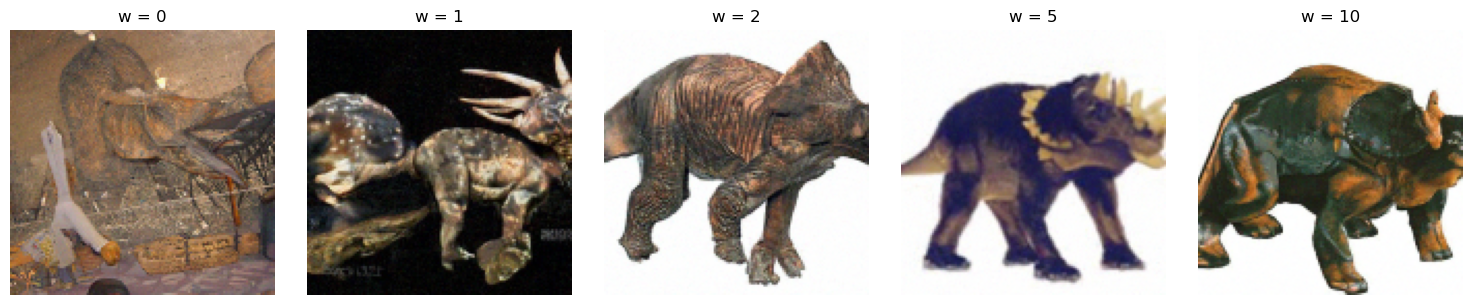

In [6]:
fig, axes = plt.subplots(1, len(w_values), figsize=(15, 3))

for ax, image, w in zip(axes, samples, w_values):
    ax.imshow(image)
    ax.set_title(f"w = {w}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Guided Samples

A guidance scale selected from the sweep is used to generate a larger batch and inspect sample diversity.

1000it [03:49,  4.36it/s]


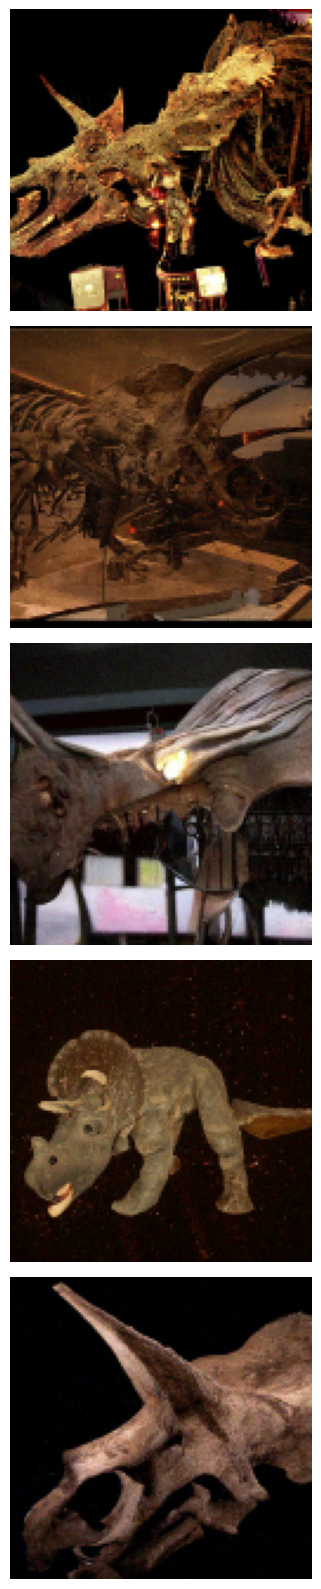

In [7]:
batch_size = 5
w = 3
x_t = torch.randn((batch_size, 3, 128, 128), device=device, dtype=torch.float32)
y = torch.Tensor([51]*batch_size).to(device).to(torch.int32)

for t in tqdm(reversed(range(T))):
    t_ = torch.Tensor([t]).to(device).to(torch.int32)
    with torch.no_grad():
        eps_prediction = model128(x_t, t_, y)[:, :3, :, :]

        with torch.enable_grad():
            x_in = x_t.detach().requires_grad_(True)
            logits = classifier128(x_in, t_)
            log_probs = F.log_softmax(logits, dim=-1)
            selected = log_probs[range(len(logits)), y.view(-1).to(torch.int64)]
            eps_prediction = eps_prediction - w * torch.autograd.grad(selected.sum(), x_in)[0] * (1-alphas[t])**0.5
        
        x_t_minus_1 = (x_t - betas[t] / (1-alphas[t])**0.5 * eps_prediction)/(1-betas[t])**0.5 + betas[t]**0.5 * torch.randn(*x_t.shape, device=device)
        x_t = x_t_minus_1

fig, axes = plt.subplots(nrows=batch_size, ncols=1, figsize=(16, 16))
for idx, ax in enumerate(axes.flatten()):
    img = (x_t[idx].permute(1,2,0).cpu().clamp(-1, 1)*127.5+127.5).numpy().astype(np.uint8)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Unconditional Sampling with Classifier Guidance

I switch to a 256×256 unconditional ImageNet diffusion model. Since the diffusion model does not receive a class label, I use the noise-aware classifier as the only source of semantic guidance.

In [18]:
class_number = 50

model256 = UNetModel(
    image_size=256,
    in_channels=3,
    out_channels=6,
    model_channels=256,
    channel_mult=(1,1,2,2,4,4),
    num_res_blocks=2,
    num_head_channels=64,
    attention_resolutions=(32,16,8),
    num_classes=None,
    resblock_updown=True,
    use_scale_shift_norm=True
)

model256.to(device)
model256.load_state_dict(torch.load('256x256_diffusion_uncond.pt'))

classifier256 = EncoderUNetModel(
    image_size=256,
    in_channels=3,
    model_channels=128,
    out_channels=1000,
    num_res_blocks=2,
    attention_resolutions=(32,16,8),
    channel_mult=(1,1,2,2,4,4),
    num_head_channels=64,
    use_scale_shift_norm=True,
    resblock_updown=True,
    pool='attention'
)

classifier256.to(device)
classifier256.load_state_dict(torch.load('256x256_classifier.pt'))

/tmp/ipykernel_1255/3173107949.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model256.load_state_dict(torch.load('256x256_diffusion_uncond.pt'))
/tmp/ipykernel_1255/3

<All keys matched successfully>

In [21]:
batch_size = 5
w = 10

x_t = torch.randn((batch_size, 3, 256, 256), device=device, dtype=torch.float32)
y = torch.Tensor([class_number]*batch_size).to(device).to(torch.int32)

for t in tqdm(reversed(range(T))):
    t_ = torch.Tensor([t]).to(device).to(torch.int32)
    with torch.no_grad():
        eps_prediction = model256(x_t, t_)[:, :3, :, :]
        
        with torch.enable_grad():
            x_in = x_t.detach().requires_grad_(True)
            logits = classifier256(x_in, t_)
            log_probs = F.log_softmax(logits, dim=-1)
            selected = log_probs[range(len(logits)), y.view(-1).to(torch.int64)]
            eps_prediction = eps_prediction - w * torch.autograd.grad(selected.sum(), x_in)[0] * (1-alphas[t])**0.5
            
        x_t_minus_1 = (x_t - betas[t] / (1-alphas[t])**0.5 * eps_prediction)/(1-betas[t])**0.5 + betas[t]**0.5 * torch.randn(*x_t.shape, device=device)
        x_t = x_t_minus_1

1000it [12:23,  1.34it/s]


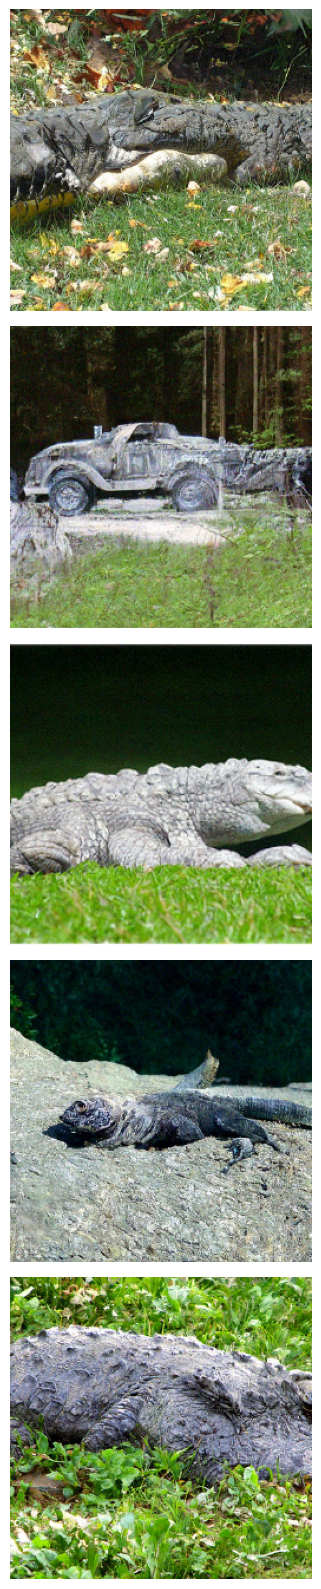

In [22]:
fig, axes = plt.subplots(nrows=batch_size, ncols=1, figsize=(16, 16))
for idx, ax in enumerate(axes.flatten()):
    img = (x_t[idx].permute(1,2,0).cpu().clamp(-1, 1)*127.5+127.5).numpy().astype(np.uint8)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Classifier-Guided Inpainting

The same unconditional diffusion model can be used for zero-shot inpainting without additional training. At every denoising step, the known region is replaced with a correspondingly noised version of the source image, while the masked region is generated under classifier guidance.

In [23]:
grass_image = np.array(Image.open('./grass.jpg'))[:256, :256]
grass_mask = np.ones_like(grass_image)*255
grass_mask[:64, :] = 0
grass_mask[-64:, :] = 0
grass_mask[:, :64] = 0
grass_mask[:, -64:] = 0

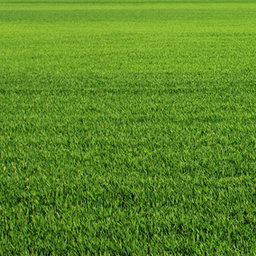

In [24]:
Image.fromarray(grass_image)

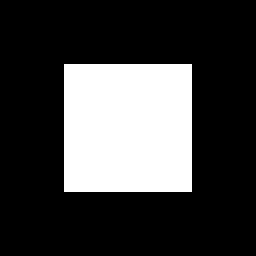

In [25]:
Image.fromarray(grass_mask)

In [26]:
grass_image = torch.from_numpy(grass_image).to(device).to(torch.float32)/127.5 - 1
grass_mask = torch.from_numpy(grass_mask).to(device).to(torch.float32)/255

grass_image = grass_image.permute(2,0,1).unsqueeze(0)
grass_mask = grass_mask.permute(2,0,1).unsqueeze(0)

In [27]:
batch_size = 5
w=10

x_t = torch.randn((batch_size, 3, 256, 256), device=device, dtype=torch.float32)
y = torch.Tensor([class_number]).to(device).to(torch.int32)
grass_image = grass_image.repeat(batch_size, 1, 1, 1)
grass_mask = grass_mask.repeat(batch_size, 1, 1, 1)

for t in tqdm(reversed(range(T))):
    t_ = torch.Tensor([t]).to(device).to(torch.int32)
    with torch.no_grad():
        grass_image_t = grass_image * alphas[t]**0.5 + (1-alphas[t])**0.5 * torch.randn(*x_t.shape, device=device)
        x_t = x_t * grass_mask + grass_image_t * (1-grass_mask)

        eps_prediction = model256(x_t, t_)[:, :3, :, :]

        with torch.enable_grad():
            x_in = x_t.detach().requires_grad_(True)
            logits = classifier256(x_in, t_)
            log_probs = F.log_softmax(logits, dim=-1)
            selected = log_probs[range(len(logits)), y.view(-1).to(torch.int64)]
            eps_prediction = eps_prediction - w * torch.autograd.grad(selected.sum(), x_in)[0] * (1-alphas[t])**0.5

        
        x_t_minus_1 = (x_t - betas[t] / (1-alphas[t])**0.5 * eps_prediction)/(1-betas[t])**0.5 + betas[t]**0.5 * torch.randn(*x_t.shape, device=device)
        x_t = x_t_minus_1

1000it [12:23,  1.34it/s]


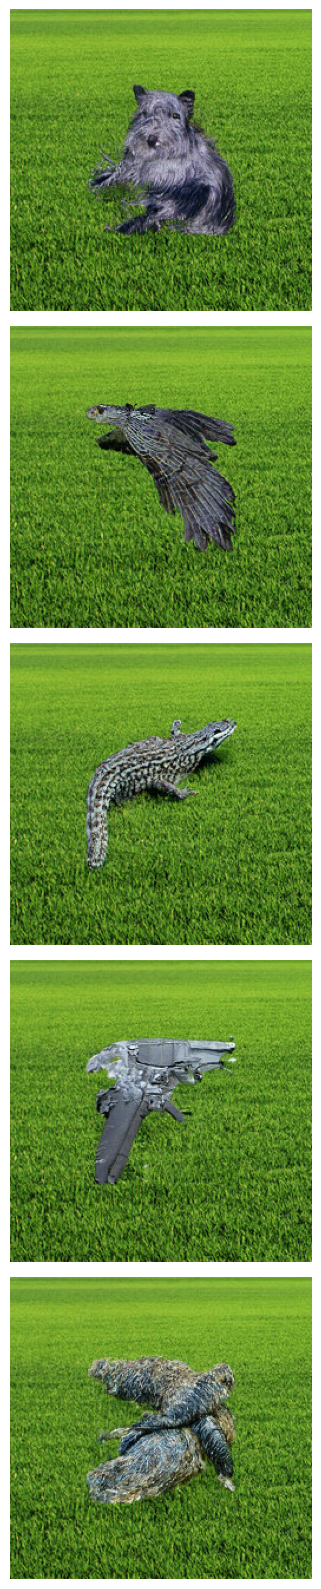

In [28]:
fig, axes = plt.subplots(nrows=batch_size, ncols=1, figsize=(16, 16))
for idx, ax in enumerate(axes.flatten()):
    img = (x_t[idx].permute(1,2,0).cpu().clamp(-1, 1)*127.5+127.5).numpy().astype(np.uint8)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()